## Matrix Methods in Data Mining and Pattern Recognition
U.I. 04.03.2025

In [113]:
using VMLS, LinearAlgebra, Plots, Statistics

# Singular Value Decomposition (Chapter 6 in MMDPR)

Although the __QR decomposition__ is highly useful for solving least squares problems,
and has excellent numerical properties, it has a drawback in only providing an orthonormal basis for the column space of a matrix...


## The Decompsition (6.1)
The [__singular value decomposition (SVD)__](https://en.wikipedia.org/wiki/Singular_value_decomposition) is a more sophisticated matrix factorization method. It simultaneously __deals with both the column- and row spaces__ of a matrix by __providing orthonomal bases for both__ in a symmetric fashion. 

Hence, it supplies __more essential information about a matrix__ than any other matrix factorization method. 

It also provides __a componentwise “ordering” of the information__ contained in the matrix by quantifying the "dominance" of the various components. Due to this property, the SVD turns out to be a very __powerful tool__ in data science applications, machine learning and other areas.

The SVD uniquely __sorts the information content of a matrix__ so that its “dominant parts” becomes easily accessible. This is what makes the SVD so useful in both machine learning and may other areas of applied mathematics.

---

Supplementary [**video lecture about the SVD** (by Gilbert Strang)](https://ocw.mit.edu/courses/mathematics/18-065-matrix-methods-in-data-analysis-signal-processing-and-machine-learning-spring-2018/video-lectures/lecture-6-singular-value-decomposition-svd/) if you are familiar with the [eigendecomposition of a symmetric matrix](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix#Real_symmetric_matrices):


In [114]:
using ShortCodes
YouTube("rYz83XPxiZo",0,21)

https://www.youtube.com/watch?v=rYz83XPxiZo&start=21

<div style="page-break-after: always;"></div>

---

### Theorem 6.1 (SVD):
Any $m \times n$ matrix $A$, with $m ≥ n$, can be factorized

$$A=U\begin{bmatrix}
\Sigma\\
0
\end{bmatrix}V^T,$$

where $U$ is orthogonal $m\times m$, $V$ __is orthogonal__ $n\times n$, and $\Sigma$ is $n\times n$ __diagonal__,

$$\Sigma = diag(\sigma_1, \sigma_2,...,\sigma_n),$$
$$\sigma_1\geq\sigma_2\geq\cdots\sigma_n\geq0.$$

__Proof:__  

Se chapter 6.1 in MMDPR. (NOTE: This proof is different from the proof you may have seen in courses like MATH280.)

--

The columns of $U$ and $V$ are called the left- and right __singular vectors__, respectively, and the diagonal (scalar) elements $\sigma_1,\cdots,\sigma_n$ are called the __singular values__.

Besides being an important theoretical result, the SVD-theorem is supported by highly efficient and accurate [**numerical algorithms for computing the SVD**](https://en.wikipedia.org/wiki/Singular_value_decomposition#Calculating_the_SVD) (see also section 6.8 in MMDPR) for large matrices.

<div style="page-break-after: always;"></div>

---

### __The thin SVD__

In the above factorization, the matrix $\begin{bmatrix}
\Sigma\\
0
\end{bmatrix}$ is $m\times n$, where the $0$ bottom part has $m-n$ rows. 

Therefore, we can represent $U = [U_1\ U_2]$, where $U_1$ is $m\times n$ and note that $U\begin{bmatrix}
\Sigma\\
0
\end{bmatrix} = U_1\Sigma.$

Consequently, we obtain [the __thin__ SVD](https://en.wikipedia.org/wiki/Singular_value_decomposition#Thin_SVD) of $A$ by

$$A = U_1\Sigma V^T,$$

that is often __most appropriate for practical applications__.

<div style="page-break-after: always;"></div>

---

Pictorially we can think of the SVD as follows

<center><img src="SVD_full.png" width="500"/></center> 

<div style="page-break-after: always;"></div>

and by __ignoring the last $m-n$ columns of__ $U$ __that are not contained in the column space of the matrix__ $A$ we obtain the corresponding "thin" version of the SVD:

<center><img src="SVD_thin2.png" width="600"/></center> 

<div style="page-break-after: always;"></div>

---

### The outer product form of the SVD

If we consider the associated matrix equations of the thin SVD including only $n$ columns in $U$, i.e.

$$AV = U_1\Sigma,\ \ \ A^tU_1 = V\Sigma,$$
    
we obtain the equations

$$Av_i=\sigma_iu_i,\ A^Tu_i=\sigma_iv_i,\text{ for }i=1,...,n.$$

Moreover, by considering $U_1=[u_1\ u_2\ \cdots\ u_n]$ and $V=[v_1\ \cdots\ v_n]$ one can express

$$ A= U_1\Sigma V^T = [u_1\ u_2\ \cdots\ u_n]
\begin{bmatrix}
\sigma_1 &  &  &  \\ 
 &  \sigma_2 &  & \\ 
 &  & \ddots & \\ 
 &  &  &  \sigma_n 
\end{bmatrix}
\begin{bmatrix}
v_1^T\\
v_2^T\\
:\\
v_n^T
\end{bmatrix}$$
$$=[u_1\ u_2\ \cdots\ u_n]\begin{bmatrix}
\sigma_1v_1^T\\
\sigma_2v_2^T\\
:\\
\sigma_n v_n^T
\end{bmatrix}= \sum_{i=1}^n\sigma_iu_iv_i^T.$$

The latter expansion of $A$ as a sum of rank $1$ matrices is often referred to as the [__outer product form__ of the SVD](http://mlwiki.org/index.php/Singular_Value_Decomposition#Outer_Product_Form).

---

### Example 6.2.
Compute the __full__ and the __thin__ [SVD in Julia](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) of the following matrix $A$ with full column rank:

In [115]:
A = [1 1; 1 2; 1 3; 1 4]

4×2 Matrix{Int64}:
 1  1
 1  2
 1  3
 1  4

In [116]:
# The full SVD
U,σ,V = svd(A; full = true)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
4×4 Matrix{Float64}:
 -0.219529   0.807346    0.0236068   0.547214
 -0.383342   0.391214   -0.439345   -0.712023
 -0.547155  -0.0249171   0.807869   -0.217595
 -0.710969  -0.441048   -0.392131    0.382405
singular values:
2-element Vector{Float64}:
 5.779378813233887
 0.7738091063972269
Vt factor:
2×2 Matrix{Float64}:
 -0.322006  -0.946738
  0.946738  -0.322006

In [117]:
# Here, the two last U-columns are orthogonal to the A-columns:

U[:,3:4]'A

2×2 Matrix{Float64}:
 -1.11022e-16  0.0
 -5.55112e-17  0.0

<div style="page-break-after: always;"></div>

In [118]:
# The thin SVD (this is the default in Julia)
U,σ,V = svd(A; full = false)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
4×2 Matrix{Float64}:
 -0.219529   0.807346
 -0.383342   0.391214
 -0.547155  -0.0249171
 -0.710969  -0.441048
singular values:
2-element Vector{Float64}:
 5.779378813233887
 0.7738091063972269
Vt factor:
2×2 Matrix{Float64}:
 -0.322006  -0.946738
  0.946738  -0.322006

In [119]:
B = [A 3*U[:,1]]

U,σ,V = svd(B; full = false)


SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
4×3 Matrix{Float64}:
 -0.219529   0.807346   -0.338897
 -0.383342   0.391214    0.772581
 -0.547155  -0.0249171  -0.528471
 -0.710969  -0.441048    0.0947871
singular values:
3-element Vector{Float64}:
 6.511621876833506
 0.773809106397227
 2.111027920454363e-16
Vt factor:
3×3 Matrix{Float64}:
 -0.285796  -0.840275   0.460715
  0.946738  -0.322006  -5.55112e-17
 -0.148353  -0.436176  -0.887548

<div style="page-break-after: always;"></div>

---


### __Matrix rank__ 
Recall that the [__rank__](https://en.wikipedia.org/wiki/Rank_(linear_algebra)) of a matrix $A$ __is defined as the dimension of__ the __vector space generated by its columns__. This number is the same as the maximal number of linearly independent columns that is possible to select from $A$. 

[In terms of singular values](https://en.wikipedia.org/wiki/Rank_(linear_algebra)#Rank_in_terms_of_singular_values), __the rank of an $m\times n$ matrix__ $A$ equals the __number of non-zero singular values__.

Hence, the rank of $A$ respects the inequality 

$$r\leq \min(m,n),$$

and if $U_r =  [u_1\ u_2\ \cdots\ u_r]$ and $V_r =  [v_1\ v_2\ \cdots\ v_r]$ denotes the left- and right singular vectors corresponding to the non-zero singular values $\sigma_1,...,\sigma_r$ forming the diagonal matrix $\Sigma_r$, we have

$$A = U_r\Sigma_rV_r^T=[u_1\ u_2\ \cdots\ u_r]
\begin{bmatrix}
\sigma_1 &  &  &  \\ 
 &  \sigma_2 &  & \\ 
 &  & \ddots & \\ 
 &  &  &  \sigma_r 
\end{bmatrix}
\begin{bmatrix}
v_1^T\\
v_2^T\\
:\\
v_r^T
\end{bmatrix}=\sum_{i=1}^r\sigma_iu_iv_i^T.$$

This version, only including information associated with the non-zero singular values is often referred to as [the **compact SVD**](https://en.wikipedia.org/wiki/Singular_value_decomposition#Compact_SVD).

---

### __Two important matrix norms__
Let 

$$A= \begin{bmatrix}
a_{11} & a_{12} & .. & a_{1n} \\ 
 a_{21} & a_{22} & .. & a_{2n} \\ 
 : & : & : & : \\ 
 a_{m1} & a_{m2} & .. & a_{mn}
\end{bmatrix}$$ 

be a matrix of rank $r$ $(\sigma_1,...,\sigma_r > 0=\sigma_{r+1}=...=\sigma_n)$. 

#### The $2$-norm (operator norm) 
The [$2$-**norm (operator norm)**](https://en.wikipedia.org/wiki/Matrix_norm#Matrix_norms_induced_by_vector_p-norms) of $A$ is  is defined as

$$\|A\|_2 \stackrel{\text{def}}{=}\max_{x\neq 0}\frac{\|Ax\|_2}{\|x\|_2}=\max_{\stackrel{x}{ \|x\|_2=1}}\|Ax\|_2,$$
and the following proposition holds:

<div style="page-break-after: always;"></div>

---

#### Proposition 6.2

$\|A\|_2$ is given by the __largest singular value__ of $A$, i.e.

$$\|A\|_2 = \sigma_1.$$

__Proof:__  
See chapter 6.1 in MMDPR.

The operator norms are **computed in Julia** by the function [`opnorm(A)`](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.opnorm). 

---

#### The Frobenius norm

The  [__Frobenius norm__](https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm) of a matrix $A$ is defined as

$$\|A\|_F\stackrel{\text{def}}{=}\sqrt{\sum_{i,j = 1}^{m,n} a_{ij}^2}.$$

When $\sigma_1,...,\sigma_r > 0$ are the non-zero singular values of $A$ (when $A$ has rank $r$), 
the following identity holds:

$$\|A\|_F = \sqrt{\sum_{i = 1}^r \sigma_i^2}.$$

The Frobenius norms are **computed in Julia** by the function [`norm(A)`](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.norm). 

In [120]:
U,σ,V = svd(A) 

# NOTE: σ₁ equals the operator norm of A, and its 
# Frobenius norm equals the sum of the squares singular values:
(opnorm(A), σ[1]), (norm(A), sqrt(sum(σ.^2)))

((5.779378813233887, 5.779378813233887), (5.830951894845301, 5.830951894845301))

---

## Fundamental subspaces (6.2)

In [121]:
#YouTube("nHlE7EgJFds",4,21)
YouTube("ggWYkes-n6E", 0, 0)

https://www.youtube.com/watch?v=ggWYkes-n6E&start=0

<div style="page-break-after: always;"></div>

The full SVD gives orthogonal bases for the __four fundamental subspaces__ of a matrix.

---

### Range (column space) of $A$

The __range__ of the $(m\times n)$ matrix $A$ is defined as the linear subspace

$$\mathscr{R}(A) = Col(A) =\{y\ \vert\ y=Ax,\text{ for arbitrary }x\in\mathbb{R}^n\}.$$

If $A$ has rank $r\leq n$, we have $\sigma_1\geq\sigma_2\geq \cdots \geq\sigma_r >\sigma_{r+1}= \cdots =\sigma_n=0$.

By considering the outer product form of the SVD of $A$, we have

$$y = Ax = \sum_{i=1}^r\sigma_iu_iv_i^Tx = \sum_{i=1}^r (\sigma_iv_i^Tx)u_i = \sum_{i=1}^r\alpha_iu_i,$$

where the coefficients $\alpha_i = \sigma_iv_i^Tx$.

--

__NOTE 1:__ $u_1,...,u_r$ is clearly an orthognal basis spanning $\mathscr{R}(A)$ that we also know as the column space $Col(A)$.

<div style="page-break-after: always;"></div>

---

### Null space of $A$

The __null-space__ of $A$ is the linear subspace

$$\mathscr{N}(A) =\{z\ \vert\ Az=0\}$$

of vectors $z$ that are __orthogonal to all rows__ in $A$.

Because 

$$Az = \sum_{i=1}^r\sigma_iu_iv_i^Tz,$$

it follows that for any 

$$z = \sum_{i=r+1}^n\beta_iv_i$$

we have $Az = 0$ (because the vectors $v_{r+1},...,v_{n}$ are all orthogonal to $v_{1},...,v_{r}$). 

--

__NOTE 2:__ Thus $v_{r+1},...,v_{n}$ is clearly an orthognal basis spanning $\mathscr{N}(A)$. 


<div style="page-break-after: always;"></div>

---

Together with a similar argument for $A^T$ we have the following result:
### Theorem 6.4 (fundamental subspaces).

If the $m\times n$ matrix $A$ has rank $r\leq n$, and its singular value decomposition is given above:

1. The singular vectors $u_1, u_2, ..., u_r$ are an orthonormal basis for $\mathscr{R}(A)$, and 

$$\text{rank}(A)=\text{dim}(\mathscr{R}(A))=r.$$

2. The singular vectors $v_{r+1}, v_{r+2}, ..., v_n$ are an orthonormal basis for $\mathscr{N}(A)$, and 

$$\text{dim}(\mathscr{N}(A))=n-r.$$

3. The singular vectors $v_1, v_2, ..., v_r$ are an orthonormal basis for $\mathscr{R}(A^T)$, and

$$\text{rank}(A^T)=\text{dim}(\mathscr{R}(A^T))=r.$$

4. The singular vectors $u_{r+1}, u_{r+2}, ..., u_m$ are an orthonormal basis for $\mathscr{N}(A^T)$, and 

$$\text{dim}(\mathscr{N}(A^T))=m-r.$$

<div style="page-break-after: always;"></div>

---

### Example 6.5 (rank deficiency)
Here we create a [rank deficient matrix](https://en.wikipedia.org/wiki/Rank_(linear_algebra)#Properties) by constructing a third column in the previous example as a linear combination of columns 1 and 2:

In [122]:
# A[:,3] = A[:,1]+0.5*A[:,2] 
A = [A A[:,1]+0.5*A[:,2]]

4×3 Matrix{Float64}:
 1.0  1.0  1.5
 1.0  2.0  2.0
 1.0  3.0  2.5
 1.0  4.0  3.0

In [123]:
U,σ,V = svd(A)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
4×3 Matrix{Float64}:
 -0.261189   0.794846    0.547214
 -0.403155   0.370764   -0.712023
 -0.545121  -0.0533178  -0.217595
 -0.687088  -0.4774      0.382405
singular values:
3-element Vector{Float64}:
 7.394388724331738
 0.9072019584831355
 3.190859464233118e-16
Vt factor:
3×3 Matrix{Float64}:
 -0.256485  -0.737209  -0.62509
  0.699836  -0.587717   0.405978
  0.666667   0.333333  -0.666667

In [124]:
rank(A)

2

---

As the third singular value is equal to zero, $A$ is rank deficient. 

Obviously, the third column of $V$ is a basis vector in $\mathscr{N}(A)$ as $Av_3 = 0$:

In [125]:
A*V[:,3]


4-element Vector{Float64}:
 -4.440892098500626e-16
 -2.220446049250313e-16
  0.0
  0.0


In the above example, the $4\times 3$ matrix $A$ has a rank of $2$ since only two of its singular values are non-zero. 

Moreover, we have the identity

$$A =\sum_{i=1}^2\sigma_iu_iv_i^T.$$

---

### Exercise 1:
Verify (in Julia) this identity for the above example.

In [126]:
A = zeros(Float64, 4,3)
for i = 1:2
    A = A + U[:,i]*σ[i]*V[:,i]'
end
 
A

# Same as
# A = (U[:,1:2].*σ[1:2]')*V[:,1:2]'

4×3 Matrix{Float64}:
 1.0  1.0  1.5
 1.0  2.0  2.0
 1.0  3.0  2.5
 1.0  4.0  3.0

---

## Matrix Approximation (6.3)

Supplementary [**video lecture about the Closest Rank $k$ Matrix to $A$** and __Principal Component Analysis__ (by Gilbert Strang)](https://ocw.mit.edu/courses/18-065-matrix-methods-in-data-analysis-signal-processing-and-machine-learning-spring-2018/resources/lecture-7-eckart-young-the-closest-rank-k-matrix-to-a/) :

In [127]:
using ShortCodes
YouTube("Y4f7K9XF04k",0,21)

https://www.youtube.com/watch?v=Y4f7K9XF04k&start=21

<div style="page-break-after: always;"></div>

### __Important:__

In many cases there are reasons to assume that $A$ is a __low-rank matrix__ plus __noise__: 

$$A = A_0 + N,$$

where the noisy part $N$ is "small" compared to $A_0$. 

Then, typically the singular values of $A$ have a behavior as illustrated in **MMDPR, Figure 6.3**. 

In [128]:
# Code for generating Figure 6.3:
m = 50; n = 20; M = rand(m,n)

U,σ,V = svd(M);

σ[1:10] = (10:-1:1); σ[11:20] = σ[11:20]./8;

A₀ = U[:, 1:10]*diagm(σ[ 1:10])*V[:, 1:10]'; # The low rank part
N = U[:,11:20]*diagm(σ[11:20])*V[:,11:20]'; # The noise part

A = A₀ + N

50×20 Matrix{Float64}:
  0.334463    0.419504   1.00517    …  -0.0487495   0.689877   -0.718738
 -0.319356    0.915134  -0.177512       1.22315     0.0402329   0.539406
  0.758275   -1.02226    0.752139      -0.5035      0.490692    1.05923
  0.195314    0.146246   0.519141       0.643595    0.84528     0.377886
  0.177739    1.11616    0.398998       0.289407   -0.0404249  -0.228698
  0.204945    1.92789   -0.625334   …   1.25111    -0.107293    0.3073
 -0.346492    0.182143  -0.240701       0.237616    0.0576148   1.06406
  1.12846    -0.134802   0.114178       0.625538    0.172124    0.955222
  0.509554   -0.4669     0.0823503     -0.0700825   0.144635    0.956842
  0.468526    0.962146   0.891913      -0.259011    0.34223    -0.917616
  ⋮                                 ⋱                          
 -0.65839     0.538397   0.0225569      0.107343    0.297227   -0.646997
  0.951848    0.877377  -0.0831086      1.45166    -0.0980913   1.10229
 -0.0828271  -1.29696    0.784707       0.

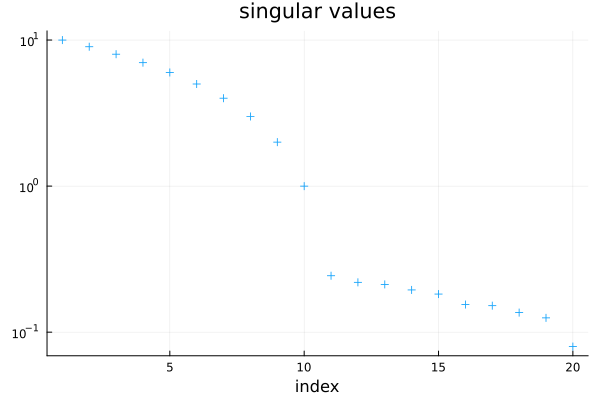

In [129]:
 scatter(σ, markershape=:plus, yaxis=:log, xlabel = "index", title="singular values", label="")

#### Figure 6.3 Singular values of a matrix of rank 10 plus noise.

In [130]:
#=
cumsum(σ)/sum(σ)

plot(σ./sum(σ), yaxis=:log, xlabel = "index", label = "σ-vals (normalized)")
plot!(cumsum(σ)/sum(σ), label = "cumsum of nomalized σ-vals", legend=:bottomleft)
=#

<div style="page-break-after: always;"></div>

<div style="page-break-after: always;"></div>

---

### __The truncated SVD__

__Gilbert Strang: "... the important facts about the matrix are in its largest $k$ singular values ..."__

See also chapter I.9 in Strangs book [__Linear Algebra and Learning from Data__](https://math.mit.edu/~gs/learningfromdata/).

In situations as described above, when the noise is sufficiently small in magnitude, the number of "large singular values" is often referred to as **the numerical rank** of the matrix. 

#### If we happen to know... 
...the correct rank of $A_0$, or can estimate it, e.g., by inspecting the singular values, then __we can “remove the noise” and approximate $A$ by a matrix of the correct rank__. 

The obvious way __to do this__ is simply to __truncate the singular value expansion__ (i.e. the above outer product expansion) to its __first $k$ terms__, where $k$ denotes the numerical rank of $A$ without noise.


<div style="page-break-after: always;"></div>

Then we approximate
$$A = \sum_{i=1}^n\sigma_iu_iv_i^T \approx \sum_{i=1}^k\sigma_iu_iv_i^T  = U_k\Sigma_kV_k^T\stackrel{\text{def}}{=:} A_k,$$
where $U_k=[u_1\ u_2\ \cdots\ u_k]$, $V_k=[v_1\ v_2\ \cdots\ v_k]$ and 

$$\Sigma_k = \begin{bmatrix}
\sigma_1 &  &  &  \\ 
 &  \sigma_2 &  & \\ 
 &  & \ddots & \\ 
 &  &  &  \sigma_k 
\end{bmatrix}.$$

The so-called [**truncated SVD**](https://en.wikipedia.org/wiki/Singular_value_decomposition#Truncated_SVD) represented by __the rank $k$-approximation__ $A_k$, is highly useful, not only for removing noise but also for compressing data (we will see this later) and for stabilizing solutions of problems including extremely ill-conditioned matrices. 

__It turns out that the truncated SVD provides the solution to approximation problems
where one wants to approximate a given matrix by a matrix of lower rank as accurately as possible:__

<div style="page-break-after: always;"></div>

---

In the following, we will consider the low-rank approximation of a matrix $A$ both in the $2$-norm and the Frobenius norm. 
First we state the theorem in terms of the [__spectral norm__ ](https://en.wikipedia.org/wiki/Matrix_norm#Matrix_Norms_induced_by_vector_p-norms)(the matrix norm induced by the vector **2-norm**):

### Theorem 6.6 ([Eckart–Young–Mirsky theorem](https://en.wikipedia.org/wiki/Low-rank_approximation#Basic_low-rank_approximation_problem) - spectral norm version).
Assume that the $m\times n$-matrix $A$ has rank $r > k$. Then the matrix approximation problem

$$\min_{\text{rank}(Z)=k}\|A-Z\|_2$$

has the truncated SVD  

$$Z=A_k = U_k\Sigma_kV_k^T,$$

as its solution, and the minimum value is

$$\|A-A_k\|_2=\sigma_{k+1},$$

i.e. the $(k+1)$-th singular value of $A$.

[A __proof__ of theorem 6.6 is givene here](https://en.wikipedia.org/wiki/Low-rank_approximation#Proof_of_Eckart%E2%80%93Young%E2%80%93Mirsky_theorem_(for_spectral_norm)).

<div style="page-break-after: always;"></div>

---

### Theorem 6.7 (Eckart–Young–Mirsky theorem - Frobenius norm version).
Assume that the $m\times n$-matrix $A$ has rank $r > k$. Then the matrix approximation problem

$$\min_{\text{rank}(Z)=k}\|A-Z\|_F$$

has the solution $Z=A_k$ (defined above), and the minimum value is

$$\|A-A_k\|_F=\sqrt{\sum_{i = k+1}^p\sigma_{i}^2},$$

where $p = \min(m,n)$.

[A __proof__ of theorem 6.7 is givene here](https://en.wikipedia.org/wiki/Low-rank_approximation#Proof_of_Eckart%E2%80%93Young%E2%80%93Mirsky_theorem_(for_Frobenius_norm)).

---
---
# Principal Component Analysis (6.4)

[Principal Component Analysis (__PCA__)](https://en.wikipedia.org/wiki/Principal_component_analysis) is __a powerful dimensionality reduction technique widely used in data analysis and machine learning__. It aims to transform a set of possibly correlated variables into a set of linearly uncorrelated (orthogonal) variables called __principal components__. 

These principal components __are ordered__ such that the __first few__ retain __most of the variation__ present in __all of the original variables combined__.

## Mathematical Formulation

Let's consider a data matrix $X$ of size $m \times n$, where $m$ is the number of observations and $n$ is the number of features. We assume that $X$ is __centered__, meaning that each original $X$-column (feature) has its mean value subtracted, so that all __the feature columns sum to zero__.

The symmetrical empirical covariance matrix $C$ of $X$ and its eigendecomposition is given by:

$$
C = \frac{1}{m-1} X^T X = V\Lambda V^T.
$$

The purpose of PCA is preciesely to obtain an orthogonal matrix $V= [v_1\ v_2\ \cdots \ v_n]$ (with columns called the __principal component loadings__) such that the transformed data 
$$T = XV,$$
(called the ___PCA scores___) have maximum variance and a diagonal covariance matrix. The latter means that the __principal component scores__ (the columns) of $T=[t_1\ t_2\ \cdots \ t_n]$ are orthogonal. 

In the diagobal matriz $\Lambda = 
\begin{pmatrix}
\lambda_1 & 0 & \cdots & 0 \\
0 & \lambda_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \lambda_n
\end{pmatrix} $
of $C$-eigenvalues, $\lambda_i$ correspond to the variance of the $i$-th principal component score $t_i$.


---
## Relationship to the Singular Value Decomposition (SVD)

Recall the (thin) Singular Value Decomposition (SVD) of $X$ (with centered columns) given by:

$$
X = U \Sigma V^T
$$

where $U$ is an $m \times n$ orthogonal matrix, $\Sigma$ is an $n \times n$ diagonal matrix with non-negative real numbers on the diagonal (singular values), and $V$ is an $n \times n$ orthogonal matrix.

The [connection between PCA and SVD](https://en.wikipedia.org/wiki/Principal_component_analysis#Singular_value_decomposition) lies in the fact that 
1. The eigenvectors of the covariance matrix $C$ are "identical" to the columns of $V= [v_1\ v_2\ \cdots \ v_n]$ found by the SVD. 
2. The $\Lambda$-eigenvalues of $C$ are obtained by squaring the singular values of $X$  and dividing by $m-1$, i.e. $\lambda_i = \frac{\sigma_i^2}{m-1}$ for $i = 1,...,n$.

---
## Steps of PCA by Singular Value Decomposition (SVD) of the centered $X$ matrix

Given a centered data matrix $X$ of size $m \times n$, we can compute the Principal Component Analysis (PCA) using its (thin) Singular Value Decomposition (SVD).

1. **Center the data:** Subtract the mean of each feature from the corresponding column of the data matrix $X$.
2. **Compute the SVD of X:**
   $$X = U \Sigma V^T$$
   where $U$ is an $m \times n$ orthogonal matrix, $\Sigma$ is an $n \times n$ diagonal matrix with non-negative singular values, and $V$ is an $n \times n$ orthogonal matrix.
3. **Principal Component directions/loadings:**
   The principal component directions (loadings) are the columns of $V$.
4. **Eigenvalues of the Covariance Matrix:**
   The eigenvalues $\lambda_i$ of the covariance matrix $C = \frac{1}{m-1} X^T X$ are related to the singular values $\sigma_i$ in $\Sigma$ by:
   $$\lambda_i = \frac{\sigma_i^2}{m-1}$$

In case of making a $k$ component PCA-model:

5. **Select the top $k$ right singular vectors:** Choose the top $k$ eigenvectors to form the matrix $V_k= [v_1\ v_2\ \cdots \ v_k]$.
6. **Project the data onto the new subspace:** Transform the data into the prinocpl components score-representation using $T_k = XV_k$.

---

## Steps of PCA by Eigendecomposition of the covariance matrix $C$

1. **Center the data:** Subtract the mean of each feature from the corresponding column of the data matrix $X$.
2. **Compute the covariance matrix and its eigen decomposition:** Calculate the empirical covariance matrix $C = \frac{1}{n-1} X^T X$.
3. **Compute the eigenvectors and eigenvalues of the covariance matrix:** Identify the principal component directions/loadings as the eigenvectors $V = [v_1\ v_2\ \cdots \ v_n]$ and eigenvalues $\lambda_i$ of $C = V\Lambda V^T$.
4. **Sort the eigenvectors by their eigenvalues:** Arrange the eigenvectors in the order of their corresponding eigenvalues, from largest to smallest.

In case of making a $k$ component PCA-model:

5. **Select the top $k$ eigenvectors:** Choose the top $k$ eigenvectors to form the matrix $V_k$.
6. **Project the data onto the new subspace:** Transform the data into the prinocpl components score-representation using $T_k = XV_k$.

---

## Interpretation

- **Principal Component Directions/Loadings:** The eigenvectors $v_i$ (columns of the $v$-matrix) are the orthonormal _principal component directions_ (often called the __PCA loadings__) representing __an alternative basis__ for the column ($n$-dimensional) space. They indicate the directions in which the data varies the most.
- **Principal Component Scores:** The transformed data $T = XV$ are called the __principal component scores__. They correspond to the representation of the original data in the principal component directions basis.
- **Variance Explained:** The eigenvalues $\lambda_i$ of $C$ represent the amount of variance explained by the principal component scores $t_i$ (the $T$-columns). 
    - The __proportion of variance__ explained by the $i$-th principal component score is calculated by $EV_i = \frac{\lambda_i}{\sum_{j=1}^n \lambda_j}$.


## Meaning in Terms of Empirical Covariance Matrix

PCA essentially __finds a new coordinate system__ for the data, where the __axes__ are the __principal component directions__. The principal components are __ordered__ in terms of the __amount of variance__ they explain. The first principal component explains the most variance, the second principal component explains the second most variance, and so on.

The __eigenvalues__ of the __covariance matrix__ $C$ represent the variance of the data along the corresponding principal component directions. By selecting the top $k$ eigenvectors, we are essentially choosing the $k$ directions that capture the maximum variance of the data when restricted to $k$ dimensions only.

---

## Advantages of PCA

- **Dimensionality Reduction:** Reduces the number of features while retaining most of the variance in the data.
- **Noise Reduction:** Can help to reduce noise in the data by discarding components with low variance.
- **Data Visualization:** Can be used to visualize high-dimensional data in a lower-dimensional space.

## Limitations of PCA

- **Linearity:** PCA is a linear technique and may not be suitable for data with non-linear relationships.
- **Sensitivity to Scaling:** PCA is sensitive to the scaling of the data. It is often important to do som standardization the data-columns before applying PCA.
- **Interpretation:** The principal components may not always have a clear physical interpretation.

---

__Note:__<br>

The __first principal component score vector__

$$t_1 (=z_1) = Xv_1=\sigma_1u_1$$

has __the largest [sample variance](https://en.wikipedia.org/wiki/Variance#Sample_variance) among all normalized linear combinations__ of the
columns of $X$:

$$Var(z_1)=Var(Xv_1)=\frac{\sigma_1^2}{m-1}.$$

Finding the linear combination of the $X$-columns with maximal variance is equivalent, in linear algebra terminology,
to maximizing the [Rayleigh quotient](https://en.wikipedia.org/wiki/Rayleigh_quotient), i.e.:

$$\sigma_1^2 := \frac{v_1^TX^TXv_1}{v_1^Tv_1}, \text{ where } v_1=\text{arg}\max_{v\neq 0}\frac{v^TX^TXv}{v^Tv}.$$

<div style="page-break-after: always;"></div>

---

Note that if $\|v_1\|\neq 1$ we can replace it by $v_1:=v_1/\|v_1\|$ so that $\sigma_1^2 = \|Xv_1\|^2= \|\sigma_1 u_1\| = \|t_1\|^2 $.

The normalized linear combination 

$$u_1 = (1/σ_1)Xv_1 = t_1/\sigma_1$$

is called __the normalized first__ principal
component __score__ of $X$.

After having determined the vector of largest sample variance, we usually want to
go on and **find the vector of second largest sample variance** that is **orthogonal to
the first** etc. 

This is done by computing the vector of largest sample variance of the deflated data matrix $X−σ_1u_1v_1^T$. By continuing this process we can determine all the principal components in order, i.e., we compute the singular vectors. In the general
step of the procedure, the subsequent principal component is defined as the vector of maximal variance subject to the  constraint that it is orthogonal to the previous ones.

---

### Example 6.9 
Illustration of PCA. See Figure 6.4 in MMDMPR that shows five hundred (500) data points generated from a correlated normal distribution and collected in a $500\times 3$ data matrix $X$. The data points and the principal components are illustrated in the top plot of the figure. The data points corresponding to the deflated the data matrix $X_1 := X − σ_1u_1v_1^T$ are given in the bottom plot.

In [131]:
M = [4*(randn(500,1)) 2*(randn(500,1)) 1*(randn(500,1))];
m̄ = mean(M, dims = 1); 
M = M.- m̄;

Q,~ = qr(randn(3,3)); Q = Matrix(Q);
X = M*Q;

U, s, V = svd(X);
s

3-element Vector{Float64}:
 90.59228564776065
 44.10649786435235
 20.992192816067064

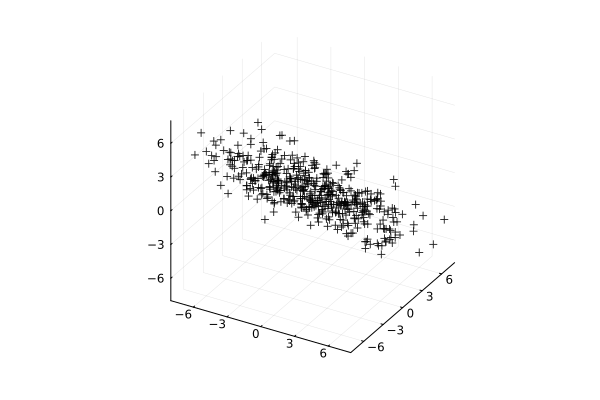

In [132]:
# Scatterplot of original 3d data
scatter(X[:,1], X[:,2], X[:,3], aspect_ratio=:equal, markershape=:plus, 
markercolor = "black", xlim = [-8, 8], ylim = [-8, 8],zlim = [-8, 8], 
type="scatter3d", label="")

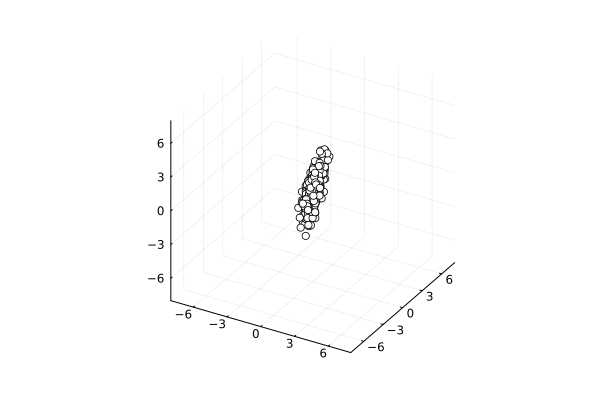

In [133]:
s0 = copy(s); s0[1] = 0; X0 = U*(s0.*V')

# "Reconstruction" of X-data where contributions in the direction of the 1st PC-score is inored
X₁ = U[:,2:3]*(s[2:3].*V[:,2:3]');
scatter(X₁[:,1], X₁[:,2], X₁[:,3], aspect_ratio=:equal, markershape=:circle, 
markercolor = "white", xlim = [-8, 8], ylim = [-8, 8], zlim = [-8, 8], 
type="scatter3d", label="")

__Figure 6.2.__  
__Top:__ Cluster of points in $\mathbb{R}^3$.  
__Bottom:__ Same data where the contributions in the subspace according to the first principal component $\sigma_1u_1v_1^T$ is
removed.

---

### The pseudo-inverse

__Definition__ ([the pseudoinverse of a matrix $A$ with __linearly independent columns__](https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse#Linearly_independent_columns))

The ___left___ _pseudo-inverse_ of a $m\times n$ matrix $A$ with column rank $k=n$ ($n$ is the number of columns in $A$, and the columns are linearly independent) is denoted $A^+$ and defined as
    
$$A^+=(A^TA)^{-1}A^T.$$
    
Note that $A^+$ is $n\times m$ and has the property $A^+A=I_n$ (__verify!__).
    
### Exercise 2:
Use the "compact" SVD of $A = U_k\Sigma_k V_k^T$ to show that
    
$$A^+=V_k\Sigma_k^{-1}U_k^T.$$

<div style="page-break-after: always;"></div>

---

__Definition__ ([the pseudoinverse of a matrix $A$ with __linearly independent rows__](https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse#Linearly_independent_rows))

The ___right___ _pseudo-inverse_ of a $m\times n$ matrix $A$ with row rank $k=m$ ($m$ is the number of rows in $A$, and the rows are linearly independent) is also denoted $A^+$ but defined as
    
$$A^+=A^T(AA^T)^{-1}.$$
    
Note that here $A^+$ is $n\times m$ and has the property $AA^+=I_m$ (__verify!__).
    
### Exercise 3:
Use the "compact" SVD of $A = U_k\Sigma_k V_k^T$ to show that
    
$$A^+=V_k\Sigma_k^{-1}U_k^T.$$

---

### Definition (the pseudoinverse of any matrix $𝐴$)

Based on the results of exercise 2 and 3, we extend the definition of the pseudo-inverse to also include matrices $A=U_k\Sigma_k V_k^T=\sum_{i=1}^{k}\sigma_i{ v}_i{u}_i^T$ of any rank $k\leq\min(m,n)$ including the _outer product representation_:
    
$$A^+=V_k\Sigma_k^{-1}U_k^T=\sum_{i=1}^{k}\sigma_i^{-1}{v}_i{u}_i^T.$$
    

---

## Solving Least Squares Problems (6.5)
The least squares problem can be solved using the SVD. Assume that we have an
overdetermined system $Ax = b$, where the $m\times n$ matrix $A$ has full column rank ($k = n$). Write
the full SVD of $A$ by
$$A = [U_1\ U_2]\begin{bmatrix} \Sigma\\ 0 \end{bmatrix}V^T ,$$
where $U_1$ is $m\times n$. 

By using the SVD and the fact that the norm is invariant under
orthogonal transformations, we have that for $r = b-Ax$
$$\|r\|^2 = \|b-Ax\|^2 = \|b-[U_1\ U_2]\begin{bmatrix}\Sigma\\ 0 \end{bmatrix}V^Tx   \|^2$$
$$=\|\begin{bmatrix}U_1^Tb\\ U_2^Tb\end{bmatrix}- \begin{bmatrix}\Sigma V^Tx\\ 0 \end{bmatrix}\|^2=\|U_1^Tb-\Sigma V^Tx\|^2 + \|U_2^Tb\|^2,$$

and we obtain the minimum $\|r\|^2$ by choosing 

$$\hat{x} = V\Sigma^{-1}U_1^Tb.$$

---

As $\Sigma$ is diagonal, 

$$\Sigma^{-1} = \begin{bmatrix}
\sigma_1^{-1} &  &  &  \\ 
 &  \sigma_2^{-1} &  & \\ 
 &  & \ddots & \\ 
 &  &  &  \sigma_n^{-1} 
\end{bmatrix},$$

and the solution can alternatively be written as

$$\hat{x} = \sum_{i=1}^n \frac{u_i^Tb}{\sigma_i}v_i =\left( \sum_{i=1}^{n}\sigma_i^{-1}{v}_i{u}_i^T \right) b.$$

The assumption that $A$ has full column rank implies that all the singular values are nonzero: $σ_i > 0$ for  $i = 1, 2, ... , n$. We also see that in this case, the solution is unique.

<div style="page-break-after: always;"></div>

This proves the following theorem:

---

### Theorem 6.10 (least squares solution by SVD)
Let the $(m\times n)$ matrix $A$ have full column rank and thin SVD $A = U_1ΣV^T$. Then the least squares problem

$$\min_x \| Ax − b\|^2$$

has the unique solution

$$\hat{x} = \sum_{i=1}^n \frac{u_i^Tb}{\sigma_i}v_i.$$

---

### Exercise 4:
Use the last definition of the pseudo-inverse $A^+$ to show that the least squares solution of $Ax=b$ is
    
$$\hat{x}=A^+b$$
    
when $A$ has full rank. 

---

#### Example 6.11
As an example, we re-visit the least squares problem from Chapter 3.6. on [**Hooke’s law**](https://en.wikipedia.org/wiki/Hooke%27s_law) where the spring length $(l)$ depends on the force $(F)$ according to
$$l = e + \kappa F,$$

where $e$ and $\kappa$ are the constants to be determined from experimental data. In this case the matrix $(A)$ and right-hand $(b)$ side are:

In [134]:
A = [1 1; 1 2; 1 3; 1 4; 1 5]; b = [7.97; 10.2; 14.2; 16.0; 21.2];
[A b]

5×3 Matrix{Float64}:
 1.0  1.0   7.97
 1.0  2.0  10.2
 1.0  3.0  14.2
 1.0  4.0  16.0
 1.0  5.0  21.2

In [135]:
U₁,σ,V = svd(A)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
5×2 Matrix{Float64}:
 0.160007   0.75789
 0.285308   0.467546
 0.410609   0.177202
 0.535909  -0.113142
 0.66121   -0.403486
singular values:
2-element Vector{Float64}:
 7.691213134104819
 0.919369635007323
Vt factor:
2×2 Matrix{Float64}:
 0.266934   0.963715
 0.963715  -0.266934

As the two column vectors in $A$ are linearly independent, the two singular values are
both nonzero. The least squares problem is solved by $\hat{x} = V\Sigma^{-1}U_1^Tb$.

In [136]:
Σ = diagm(σ);    # The diagonal matrix containing the singular values in s.
x̂ = V*(Σ\(U₁'*b))
#x̂ = V*(σ.\U1'b) # Alternative calculation giving the same solution

2-element Vector{Float64}:
 4.236
 3.2260000000000004

---

## 6.6 Condition Number and Perturbation Theory for the Least Squares Problem

The condition number of a rectangular $m\times n$ matrix $A$ is defined in terms of the SVD. Let
$A$ have rank $k$, i.e., its singular values satisfy

$$\sigma_1\geq \sigma_2\geq ... \geq \sigma_k > \sigma_{k+1}= ... =\sigma_p=0,$$

where $p = \min(m,n)$. 

Then the __condition number__ of $A$ is defined as

$$\kappa(A) \stackrel{\text{def}}{=}\frac{\sigma_1}{\sigma_k}.$$

Note that in the case of a square, nonsingular $A$, this definition coincides with the definition given by (3.3) in MMDPR.

--

Check out __Theorem  6.12__ in MMDPR about the behavour of the least squares solution of $Ax=b$ if the coefficient matrix $A$ and the right hand side $b$ are perturbed by some $\delta A$ and $\delta b$, respectively.

It is noted that in the overdetermined case $(m>n)$, the bounding of the perturbation of the solution $\|\delta x\|_2$ depends on the squared condition number $(\kappa^2)$ that may be a very large number unless the residual $\|r\|_2=\|Ax-b\|_2$ is very small.

---

### Exercise 5:
Study the following Julia-example illustrating the consequences of poor conditioning:

In [137]:
# Condition numbers and consequences:
# -----------------------------------

# Lets consider the coefficient matrix:
A = [10 7 8 7; 7 5 6 5; 8 6 10 9;  7 5 9 10; 8 6 10 9]


5×4 Matrix{Int64}:
 10  7   8   7
  7  5   6   5
  8  6  10   9
  7  5   9  10
  8  6  10   9

In [138]:
U, σ, V = svd(A) # SVD of A
# opnorm(pinv(A))

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
5×4 Matrix{Float64}:
 -0.461536  -0.660788   0.305255    0.507113
 -0.332182  -0.428352  -0.0346593  -0.839624
 -0.483703   0.205766  -0.461061    0.105425
 -0.45684    0.543318   0.693155   -0.125058
 -0.483703   0.205766  -0.461061    0.105425
singular values:
4-element Vector{Float64}:
 34.60132260340479
  3.9674494817680115
  1.003849287022214
  0.010262244978207444
Vt factor:
4×4 Matrix{Float64}:
 -0.516678  -0.375139  -0.562724  -0.525029
 -0.632867  -0.398618   0.289547   0.597282
  0.283944  -0.103077  -0.745877   0.593649
  0.501896  -0.830512   0.20778   -0.123201

In [139]:
# In Julia we can compute the condition number of A by eiter
ct = σ[1]/σ[end]
# or
cond(A)

# Inspect:
ct, cond(A), σ

(3371.710836847394, 3371.710836847394, [34.60132260340479, 3.9674494817680115, 1.003849287022214, 0.010262244978207444])

In [140]:
# Lets solve Ax = b wrt x for
b =[32 23 33 31 33]';
x = A\b

4×1 Matrix{Float64}:
 1.0000000000000822
 0.9999999999998641
 1.0000000000000357
 0.9999999999999779

In [141]:
# Now, consider the system Ax₀ = b₀, where b₀ is the following perturbation of the right hand side b:
b₀ =[32.1 22.9 33.1 30.9 32.9]';
x₀ = A\b₀

4×1 Matrix{Float64}:
   8.200000000000948
 -10.900000000001555
   4.000000000000379
  -0.800000000000226

---

__Note that__ the two _right hand side_ vectors $b$ and $b₀$ are quite similar, so that one would expect
the corresponding solution vectors $x$ and $x₀$ also to be quite similar(?). Clearly, this is not the case here as we obatin ... :

In [142]:
norm(b-b₀), norm(x-x₀)

(0.22360679774998216, 14.341896666760958)

__By comparing__ $x_0$ and $x$, we must __conclude that relatively small errors/changes in $b$ in this particular case implies drastical changes in the solutions__.

This phenomenon is a consequence of the coefficient matrix $A$ beeing __poorly conditioned__.

---
The following alternative coefficient matrix $AA$ is __more well-conditioned__:

In [143]:
AA = [10 8 5 2; 8 5 6 5; 5 6 10 9;  2 5 9 10; 3 6 10 9] #A = [10 7 8 7; 7 5 6 5; 8 6 10 9;  7 5 9 10; 8 6 10 9]

5×4 Matrix{Int64}:
 10  8   5   2
  8  5   6   5
  5  6  10   9
  2  5   9  10
  3  6  10   9

In [144]:

U1, σ1, V1 = svd(AA) # SVD of A
# The condition number for AA:
ct1 = σ1[1]/σ1[end]
# alternatively
cond(AA)
# is much smaller than for cond(A) above:
cond(AA), cond(A)

(37.5914408080999, 3371.710836847394)

In [145]:
σ1

4-element Vector{Float64}:
 30.22547274223168
 10.162345033120824
  1.8711069813829113
  0.8040519887633291

Now, lets solve both $AAxx = b$ and $AAxx₀ = b₀$ and compare with the above results:

In [146]:
# Solve (AA)x = b 
b =[32 23 33 31 33]';
xx = AA\b

4×1 Matrix{Float64}:
 -0.37930227113088283
  4.333458206509015
 -0.2964177007726568
  1.2721142589557513

In [147]:
# SOlve AAx₀ = b₀, where b₀ is is the same perturbation of b
b₀ =[32.1 22.9 33.1 30.9 32.9]';
xx₀ = AA\b₀

4×1 Matrix{Float64}:
 -0.39028330601732664
  4.336951533598689
 -0.23870287988761382
  1.209510653242799

In [148]:
# Here, the two vectors b and b0₀ are quite similar,
# and because AA is more well conditioned
# the two solution vectors xx and xx₀ are now correspondingly similar:
norm(b-b₀), norm(xx-xx₀)

(0.22360679774998216, 0.0859243763980171)

<div style="page-break-after: always;"></div>

---

## 6.7 Rank-Deficient and Underdetermined Systems
Assume that $A$ is rank-deficient, i.e. $\text{rank}(A) = k < \min(m, n)$. Then the least squares
problem $Ax=b$ can still be solved, but __the solution is no longer unique__. 

In this case we write the full SVD by

$$A = [U_1 U_2]\begin{bmatrix} \Sigma_1 & 0\\ 0 & 0\end{bmatrix}\begin{bmatrix}V_1^T\\ V_2^T\end{bmatrix},$$

where $U_1$ is $m\times k$, $V_1$ is $n\times k$ and $\Sigma_1$ is $k\times k$ with nonzero diagonal elements.

The norm of the residual vector $r$ can therefore be written

$$\|r\|^2 = \|Ax-b\|^2=\|[U_1 U_2]\begin{bmatrix} \Sigma_1 & 0\\ 0 & 0\end{bmatrix}\begin{bmatrix}V_1^T\\ V_2^T\end{bmatrix}x-b\|^2.$$



<div style="page-break-after: always;"></div>

---

__By setting__

$$y = V^Tx = \begin{bmatrix}V_1^Tx\\ V_2^Tx\end{bmatrix}= \begin{bmatrix}y_1\\y_2\end{bmatrix}\ \text{  and  } \ \begin{bmatrix}b_1\\b_2\end{bmatrix}= \begin{bmatrix}U_1^Tb\\U_2^Tb\end{bmatrix},$$

and noting the invariance of the norm under orthogonal transformations (i.e. by __multiplication from the left with__ $U^T$), the residual

$$\|r\|^2=\|[U_1 \ U_2]\begin{bmatrix} \Sigma_1 & 0\\ 0 & 0\end{bmatrix}\begin{bmatrix}V_1^T\\ V_2^T\end{bmatrix}x-b\|^2=\|\begin{bmatrix} \Sigma_1 & 0\\ 0 & 0\end{bmatrix}\begin{bmatrix}y_1\\y_2\end{bmatrix}-\begin{bmatrix}b_1\\b_2\end{bmatrix}\|^2=\|\Sigma_1y_1-b_1\|^2+\|b_2\|^2.$$

We can minimize the residual by choosing $y_1 = \Sigma_1^{-1}b_1 (=  \Sigma_1^{-1}U_1^Tb)$. It is also obvious that with any choice of the vector $y_2$ in

$$y = \begin{bmatrix} \Sigma_1^{-1}b_1\\ y_2\end{bmatrix},$$

we have another solution of the least squares problem. Thus __the solution of the least squares problem is not unique__. 

<div style="page-break-after: always;"></div>

---

Because multiplication by $V^T$ is an orthogonal transformation, we have

$$\|x\|^2 = \|V^Tx\|^2 =\|V_1^Tx\|^2+\|V_2^Tx\|^2=\|y_1\|^2+\|y_2\|^2= \|y\|^2,$$

with $y_1=V_1^Tx$ and $y_2=V_2^Tx$. Because the columns of $V_2$ span the null-space of $A$, we obtain the solution of minimum norm by choosing the solution $x$ so that $y_2 = V_2^Tx = 0$. 

These observations proves the following theorem:

### Theorem 6.13 (minimum norm solution)
For a rank deficient matrix $A$ $(m\times n)$ with SVD $A = U\begin{bmatrix} \Sigma_k & 0\\ 0 & 0\end{bmatrix}V^T$, there are **infinetely many** least squares solutions to $Ax=b$. Among all these, there is one **unique solution of the smallest possible norm**, namely

$$\hat{x} = V\begin{bmatrix} \Sigma_k^{-1} & 0\\ 0 & 0\end{bmatrix}U^Tb = [V_k\ V_2]\begin{bmatrix} \Sigma_k^{-1} & 0\\ 0 & 0\end{bmatrix}\begin{bmatrix}U_k^T\\U_2^T\end{bmatrix}b = V_k\Sigma_k^{-1}U_k^Tb = A^+b.$$


<div style="page-break-after: always;"></div>


---

### Underdetermined linear systems
The SVD can also be used to solve systems with more unknowns than equations (underdetermined linear systems). For an $(m\times n)$ matrix $A$ of rank $k$ with $n>m$, the SVD of $A$ is

$$A = U[\Sigma \ \ 0]\begin{bmatrix}V_1^T\\ V_2^T\end{bmatrix} = U_k\Sigma_kV_k.$$

When $V_k = V_1$ is $m\times m$, the rows of $A$ are linearly independent and $\Sigma=\Sigma_k$ is non-singular ($A$ has full row rank in this case).

Underdetermined systems $Ax=b$ can still be solved, but also in this case there is no longer a unique solution $\hat{x}$. 

<div style="page-break-after: always;"></div>

---

### Theorem 6.13 (minimum norm solution - alternative formulation)
    
If $rank(A)=k<n$, then there are infinitely many least squares solutions of $A{ x}={b}$. Among all the least squares solutions, the particular solution
    
$$\hat{x}_0=V_k\Sigma_k^{-1}U_k^T{b} = A^+{b}$$
    
has the smallest possible norm.  
    
__Proof:__   
It is clear that $\hat{x}_0\in Col(V_r) = Col(A^t)$, i.e. the solution $\hat{x}_0$ is a linear combination of the right singular vectors ${V}_k = A^tU_k\Sigma_k^{-1}$ that are all linear combinations of the rows in $A$. The assumption $k < n$ implies that the null-space $\mathscr{N}(A)\neq \{0 \}$ ($\dim(\mathscr{N}(A))=n-k$). 
    
Let $\hat{x}\neq \hat{x}_0$ be any least squares solution, i.e.
$A\hat{x}=\hat{b}$, where $\hat{b}$ is the projection of ${b}$ onto $Col(A)$.
Then $A\hat{x}=\hat{b}=A\hat{x}_0$ and therefore $A(\hat{x}-\hat{x}_0)=\hat{b}-\hat{b}={0}$, i.e. $(\hat{x}-\hat{x}_0)\in \mathscr{N}(A)$. 

The latter means that $(\hat{x}-{x}_0)$ is orthogonal to the rows in $A$, as well as any linear combination of these rows, such as $\hat{x}_0$.
    
Therefore, by [**Pythagoras theorem**](https://en.wikipedia.org/wiki/Pythagorean_theorem) we have

$$\|\hat{x}\|^2=\|(\hat{x}-\hat{x}_0)+\hat{x}_0\|^2=\|\hat{x}-\hat{x}_0\|^2+\|\hat{x}_0\|^2 > \|\hat{x}_0\|^2.$$

Finally we note that for any vector ${v}\in \mathscr{N}(A)$, $\hat{x}=\hat{x}_0+{v}$ is a least squares solution because 

$$A\hat{x}=A(\hat{x}_0+{v})=A\hat{x}_0+A{v}=\hat{b}+{0}=\hat{b},$$

and because $\mathscr{N}(A)\neq \{0 \}$ there are infinitely many choices for ${v}\ \blacksquare$


---

### Exercise 6:   
Verify that $\hat{x}_0=V_k\Sigma_k^{-1}U_k^t{b}$ above really is a least sqares solution of $A{x}={b}$ when $rank(A)=k<n$.

(**Hint:** The normal equations.)

---

### Exercise 7:
Here you can see how to do [PCA in Julia using the MultivariateStats package](https://juliastats.org/MultivariateStats.jl/stable/pca/).

You should also consider the following Julia-function `myPCA` where [Principal Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) based on the SVD is implemented in full detail (see "Steps of PCA by Singular Value Decomposition (SVD) of the centered $X$ matrix" above):

In [149]:
using LinearAlgebra
using Statistics

function myPCA(X; nc = 2)   
# T, σ², x̄, V, s, U = myPCA(X)
# X  - a data matrix
# nc - the requested number of components to be returned
# ------------------------------------------------------------------
# Principal Component Analysis of data-matrix X (the input argument)
# ------------------------------------------------------------------
# The function returns
# T  - matrix of PCA-scores
# σ² - the PCA-variances
# sσ² - the total variance     
# x̄ - row vector of the X-column mean values
# ---
# From the svd of the centered X-data matrix we have:
# V  - the PCA-loadings (the right singular vectors)
# s  - the singular values (of the centered X-data matrix)
# U  - the normalized prinicpal component scores (the left singular vectors)

m,n = size(X)            # Number of rows and columns in X
x̄   = mean(X, dims=1)    # The X-column mean values
U, s, V = svd(X.-x̄);     # SVD of the centered X-data
σ²  = (s.^2)./(m-1);     # the PCA-score variances   
sσ² = sum(σ²);           # the total variance in the dataset    
nc  = min(nc, min(n,m))  # Assure that the requested number of extracted components is consistent with the size of X.
σ²  = σ²[1:nc];          # PCA-score variances of the requested components
U   = U[:,1:nc]; s = s[1:nc]; V = V[:,1:nc]; # The SVD-results of the requested components.
T   = U.*s'              # the PCA-scores

return T, σ², sσ², x̄, V, s, U;
end

myPCA (generic function with 1 method)

---

In the following we will compare the two alternatives in an application to the [**Iris flower dataset**](https://en.wikipedia.org/wiki/Iris_flower_data_set):

In [150]:
# import Pkg; Pkg.add("MultivariateStats"); Pkg.add("RDatasets")
using MultivariateStats, RDatasets, Plots

# load iris dataset
iris = dataset("datasets", "iris")

# split half to training set
Xtr = Matrix(iris[1:2:end,1:4])
Xtr_labels = Vector(iris[1:2:end,5])

# split other half to testing set
Xte = Matrix(iris[2:2:end,1:4])
Xte_labels = Vector(iris[2:2:end,5]);

In [151]:
# Execute the PCA by the myPCA-function
md = 3; # The number of compoenets we want to extract in the PCA
T, σ², sσ², x̄, V, s, U = myPCA(Xtr; nc = md);

<div style="page-break-after: always;"></div>

---

**To do:**  
Consider the outputs when calling 
```Julia
md = 3; # The number of compoenets we want to extract in the PCA
T, σ², sσ², x̄, V, σ, U = myPCA(Xtr; nc = md);
``` 
above. 

Then carefullt try to **indetify the field contents** produced by Julias PCA in when calling:

```Julia
M = fit(PCA, Xtr'; maxoutdim = md);
```
__Note:__<br>
As Julias PCA considers data matrices organized in transposed format `Xtr'` compared to the matrices defined on our notation, we must input them in transposed version to obtain outputs consistent with the outputs of the `myPCA`-function.

In [152]:
# By taking Xtr and Xte as training- and testing data matrix, we train a PCA model including the first md = 3 dimensions:
M = fit(PCA, Xtr'; maxoutdim = md);

__Note:__<br>
The resulting PCA-model `M` has the following field names (check `fieldnames(PCA)`) 
* `mean`: (`M.mean`)
* `proj`: (`M.proj`)
* `prinvars`: (`M.prinvars`)
* `tprinvar`: (`M.tprinvar`)
* `tvar`: (`M.tvar`)

You should inspect all these fields and try to identify the same numbers from the outputs of 
```Julia
T, σ², sσ², x̄, V, σ, U = myPCA(Xtr'; nc = md);
``` 

(This exercise is closely related to the [PCA on _Iris_ data set example](https://juliastats.org/MultivariateStats.jl/stable/pca/#Example) in the [MultivariateStats.jl package documentation](https://juliastats.org/MultivariateStats.jl/dev/).)

In [153]:
# M.mean      # compare to x̄
# M.proj      # compare to V
# M.prinvars  # compare to σ²
# M.tprinvar  # compare to ??, 
# M.tvar      # sompare to ?? sσ²

#V.*sqrt.(σ²')

In [154]:
#M.mean
#[ M.mean x̄']
#[M.proj V]
# M.prinvars,  σ²
M.tprinvar , sum(σ²)

(4.6234752426987855, 4.623475242698791)

In [155]:
# The test-set scores based on the Julia PCA model (M):
Yte = predict(M, Xte')'

75×3 adjoint(::Matrix{Float64}) with eltype Float64:
  2.72714  -0.230916    0.253119
  2.75491  -0.406149    0.0271266
  2.32396   0.646374   -0.230469
  2.65105   0.0828144   0.0252853
  2.68917  -0.17411     0.231507
  2.63367  -0.0825183  -0.0820979
  3.22638  -0.614305    0.0211085
  2.44774   1.22392    -0.406469
  2.67677   0.228492   -0.0386127
  2.62391   0.403933   -0.248976
  ⋮                    
 -1.42529  -0.0830416   0.181381
 -3.0342    0.833224    0.269449
 -1.88009   0.0858051  -0.155163
 -2.07575   0.444162   -0.0540889
 -1.89212   0.476081   -0.1407
 -2.53304   0.329041   -0.309265
 -1.92047   0.246554   -0.180044
 -1.74161   0.127625   -0.123165
 -1.37706  -0.280295   -0.314992

In [156]:
# Compute the test-set scores based on output from the myPCA-function:
TSs = (Xte .- x̄)*V


75×3 Matrix{Float64}:
 -2.72714   0.230916    0.253119
 -2.75491   0.406149    0.0271266
 -2.32396  -0.646374   -0.230469
 -2.65105  -0.0828144   0.0252853
 -2.68917   0.17411     0.231507
 -2.63367   0.0825183  -0.0820979
 -3.22638   0.614305    0.0211085
 -2.44774  -1.22392    -0.406469
 -2.67677  -0.228492   -0.0386127
 -2.62391  -0.403933   -0.248976
  ⋮                    
  1.42529   0.0830416   0.181381
  3.0342   -0.833224    0.269449
  1.88009  -0.0858051  -0.155163
  2.07575  -0.444162   -0.0540889
  1.89212  -0.476081   -0.1407
  2.53304  -0.329041   -0.309265
  1.92047  -0.246554   -0.180044
  1.74161  -0.127625   -0.123165
  1.37706   0.280295   -0.314992

In [157]:
# Test data reconstruction based on the myPCA-model
# Xr2 = ((Xte .- x̄)*V)*V' .+ x̄
Xr2 = TSs*V' .+ x̄

75×4 Matrix{Float64}:
 4.86449  3.04262  1.46099  0.10362
 4.61087  3.08695  1.48132  0.229519
 5.40782  3.89061  1.68656  0.421233
 5.00775  3.39069  1.48668  0.221041
 4.90864  3.08963  1.48516  0.123445
 4.83689  3.35572  1.53664  0.300129
 4.2924   3.00912  1.11305  0.0793783
 5.70443  4.39468  1.49239  0.412022
 5.07459  3.53051  1.44365  0.23102
 5.11627  3.78046  1.47204  0.344176
 ⋮                          
 6.3575   2.73097  5.00123  1.65608
 7.63103  3.08279  6.21847  2.11279
 6.46791  3.01847  5.38334  1.98435
 6.85145  3.15828  5.4834   1.96821
 6.76852  3.25784  5.32585  1.9431
 6.79346  3.20785  5.91124  2.28224
 6.58825  3.13416  5.39197  1.99665
 6.46774  3.03873  5.25542  1.91243
 5.94384  2.94737  5.02469  1.91901

In [158]:
# The rank 3 approximation of the test data  based on the Julia PCA model (M):
Xr1 = reconstruct(M, Yte')'

75×4 adjoint(::Matrix{Float64}) with eltype Float64:
 4.86449  3.04262  1.46099  0.10362
 4.61087  3.08695  1.48132  0.229519
 5.40782  3.89061  1.68656  0.421233
 5.00775  3.39069  1.48668  0.221041
 4.90864  3.08963  1.48516  0.123445
 4.83689  3.35572  1.53664  0.300129
 4.2924   3.00912  1.11305  0.0793783
 5.70443  4.39468  1.49239  0.412022
 5.07459  3.53051  1.44365  0.23102
 5.11627  3.78046  1.47204  0.344176
 ⋮                          
 6.3575   2.73097  5.00123  1.65608
 7.63103  3.08279  6.21847  2.11279
 6.46791  3.01847  5.38334  1.98435
 6.85145  3.15828  5.4834   1.96821
 6.76852  3.25784  5.32585  1.9431
 6.79346  3.20785  5.91124  2.28224
 6.58825  3.13416  5.39197  1.99665
 6.46774  3.03873  5.25542  1.91243
 5.94384  2.94737  5.02469  1.91901

In [159]:
# Goodness of the Xr1 test data approximation compared to the Xte test data (0 is perfect)
norm(Xte-Xr1)/norm(Xr1)

0.021487294938371735

In [160]:
# Compute rank 3 approximation of the test data based on output from the myPCA-function:
Xr2 = ((Xte .- x̄)*V)*V' .+ x̄

75×4 Matrix{Float64}:
 4.86449  3.04262  1.46099  0.10362
 4.61087  3.08695  1.48132  0.229519
 5.40782  3.89061  1.68656  0.421233
 5.00775  3.39069  1.48668  0.221041
 4.90864  3.08963  1.48516  0.123445
 4.83689  3.35572  1.53664  0.300129
 4.2924   3.00912  1.11305  0.0793783
 5.70443  4.39468  1.49239  0.412022
 5.07459  3.53051  1.44365  0.23102
 5.11627  3.78046  1.47204  0.344176
 ⋮                          
 6.3575   2.73097  5.00123  1.65608
 7.63103  3.08279  6.21847  2.11279
 6.46791  3.01847  5.38334  1.98435
 6.85145  3.15828  5.4834   1.96821
 6.76852  3.25784  5.32585  1.9431
 6.79346  3.20785  5.91124  2.28224
 6.58825  3.13416  5.39197  1.99665
 6.46774  3.03873  5.25542  1.91243
 5.94384  2.94737  5.02469  1.91901

In [161]:
# Goodness of the Xr2 test data approximation compared to the Xr1 approximation (0 is perfect)


In [162]:
# Compare the reconstructions Xr1 and Xr2
Xr2 ≈ Xr1, norm(Xr2-Xr1)

(true, 2.040486021969573e-14)

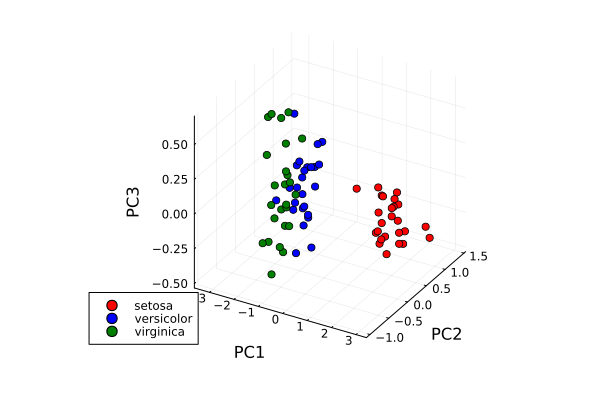

In [163]:
# Create a 3D scatter plot based on the test set scores:

setosa     = Yte[Xte_labels.=="setosa",:]       # Test set scores for the setosas
versicolor = Yte[Xte_labels.=="versicolor",:]   # Test set scores for the versicolors
virginica  = Yte[Xte_labels.=="virginica",:];   # Test set scores for the virginicas

p = scatter3d(
    setosa[:, 1], setosa[:, 2], setosa[:, 3],
    marker = :circle,
    markercolor = :red,
    markersize = 4,
    linewidth = 0,
    label = "setosa"
)

scatter3d!(
    versicolor[:, 1], versicolor[:, 2], versicolor[:, 3],
    marker = :circle,
    markercolor = :blue,
    markersize = 4,
    linewidth = 0,
    label = "versicolor"
)

scatter3d!(
    virginica[:, 1], virginica[:, 2], virginica[:, 3],
    marker = :circle,
    markercolor = :green,
    markersize = 4,
    linewidth = 0,
    label = "virginica"
)

# Add labels
plot!(p,xlabel="PC1", ylabel="PC2", zlabel="PC3")

# Display the plot (it will be interactive)
display(p)